# Example of cut and flow analysis with HydroRoot

>- In the following there are successive cells with code lines to run and some explanations.
>- Cells with code lines have a number at their top left corner
>- Run the cells with code lines with Ctrl+Enter

## First: some needed code
- to indicate where are the library files of HydroRoot
- to display inline plots in the notebook

In [1]:
# to display inline plots in the notebook
%matplotlib inline

## Before running the script

- prepare the input yaml file
- add the experimental data point to the comma separated csv file data/cnf_data.csv

### Yaml file:
It contains different input categories that are explained in the example hydroroot/example/parameters_Ctr-3P2.yml.
>modify and duplicate the file

### the cnf_data file:
>Download *data/maize_cnf_data.csv*, add the data and upload it back

csv file containing cut and flow:

**mendatory columns**:
- arch: name of the architecture file without extension. The file given in 'input_file' of the yaml file
- dP_Mpa: column with the working cut and flow pressure
- J0, ..., Jn: columns containing the flux values, 1st for the full root, then 1st cut, 2d cut, etc.
- lcut1, ...., lcutn: columns containing the maximum length to the base after each cut, 1st cut, 2d cut, etc. (not length for full root)

**optional columns**
- last columns **used only if dP is not constant**:
    - dP0, dP1,.., dPn: containing the working pressure of each steps: full root, 1st cut, 2d cut, etc.
    
**Example**

|arch|dP_Mpa|J0|J1|J2|J3|J4|J5|J6|J7|J8|J9|lcut1|lcut2|lcut3|lcut4|lcut5|lcut6|lcut7|lcut8|lcut9|
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
|Exp03_P2|0.2|0.1|0.11|0.1|0.1|0.12|0.18|||||0.37|0.3|0.25|0.2|0.14|||||
|Exp05_P13|0.3|0.01|0.01|0.01|0.02|0.01|0.02|||||0.26|0.22|0.18|0.14|0.11|||||

## Run the script: direct simulation
- argument '-o': name of the output csv file

Simulation runs:  1
#############################
**********************
optimization finished
**********************
Exp03_P2.txt 0.434 174.7 3.979 0.005643500494241343 0.10353098834266657
Exp03_P2.txt 0.3717 174.7 3.915 0.005432385467920032 0.10453111364470544
Exp03_P2.txt 0.2966 174.7 3.829 0.005171922304196114 0.10759915265933087
Exp03_P2.txt 0.2493 174.7 3.694 0.004912382768712372 0.11072095912537126
Exp03_P2.txt 0.2035 174.7 3.468 0.0045468898793936275 0.11882128745122093
Exp03_P2.txt 0.1358 174.7 2.947 0.0037846326874823354 0.18539093509833077


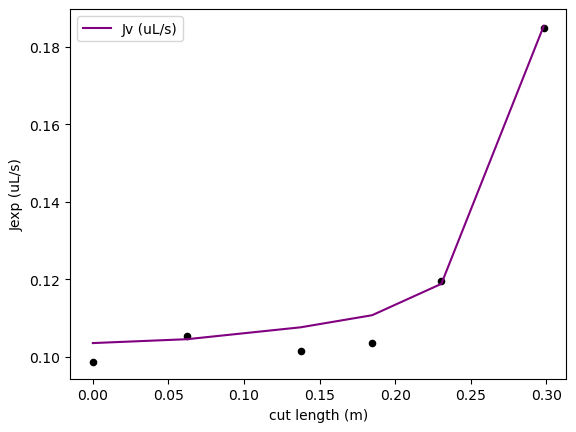

running time is  0.5252349376678467


<Figure size 640x480 with 0 Axes>

In [2]:
%run adjustment_K_and_k.py parameters_Ctr-3P2.yml -o results.csv

## Display architecture
Options:
- cut='tot' is the full root, then cut is the cut length
- prop: property to display
- perspective: activate the zoom
- azimut: axial rotation
- elevation: rotation with the root base as center of rotation
- line_width: lines width

In [3]:
plot_architecture() # function defined in adjustment_K_and_k.py

interactive(children=(Dropdown(description='cut', options=('tot', '0.3717', '0.2966', '0.2493', '0.2035', '0.1…

## Run adjustment
- adjust the radial and axial conductance
- argument:
    - '-op': indicate to run optimization
    - '-o': name of the output csv file
- running time is around 30 s on a core i7

Simulation runs:  1
#############################
finished minimize ax, ar [1.01050774 0.93375028]
**********************************
Simu,  163.12617331442004 2.244456629256886e-05 163.1427258817501 dk0 =  0.0002739874852159104 dKx =  0.003497013392198752
**********************
optimization finished
**********************
Exp03_P2.txt 0.434 163.1427258817501 3.979 0.005643500494241343 0.101804315701373
Exp03_P2.txt 0.3717 163.1427258817501 3.915 0.005432385467920032 0.10180609535735646
Exp03_P2.txt 0.2966 163.1427258817501 3.829 0.005171922304196114 0.10184194158699415
Exp03_P2.txt 0.2493 163.1427258817501 3.694 0.004912382768712372 0.10365118561148688
Exp03_P2.txt 0.2035 163.1427258817501 3.468 0.0045468898793936275 0.1195085133388621
Exp03_P2.txt 0.1358 163.1427258817501 2.947 0.0037846326874823354 0.18477876269337068
************************************************************
radial k 1st:  174.7 , k optimized:  163.1427258817501
***************************************************

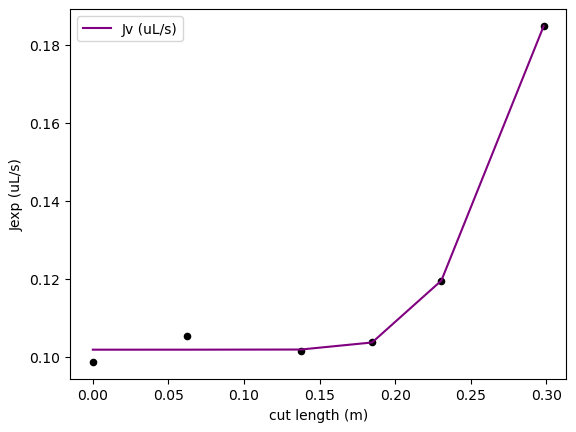

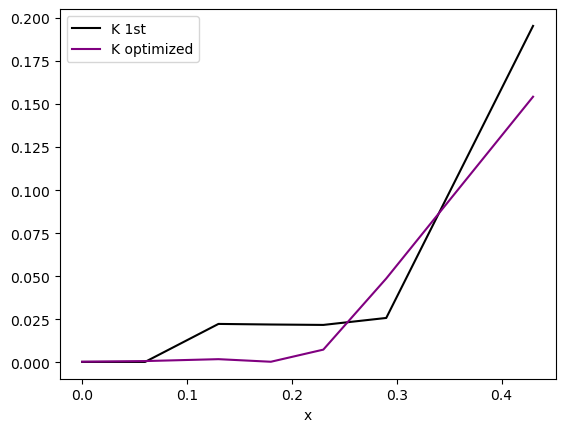

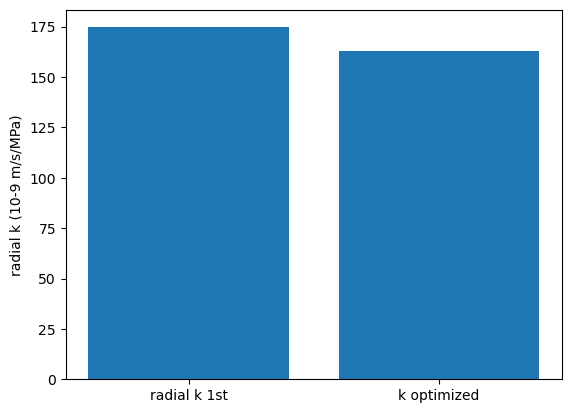

running time is  26.36724281311035


<Figure size 640x480 with 0 Axes>

In [4]:
%run adjustment_K_and_k.py parameters_Ctr-3P2.yml -op -o results.csv

In [5]:
plot_architecture()

interactive(children=(Dropdown(description='cut', options=('tot', '0.3717', '0.2966', '0.2493', '0.2035', '0.1…